# ECOWAS Border Trade Intelligence and Analytics

# Geospatial Analytics

## Impact Assessment of Simulated Regional Trade Diversion Following the AES Countries' Withdrawal from ECOWAS

### Case Study: Tsamiya–Kamba Transit Corridor

---

## Objective

This notebook demonstrates how geospatial analytics can be used to visualize border trade activity and identify strategic border locations affected by simulated trade diversion.

The analysis supports evidence-based border management by combining transaction data with geographic information.

In [50]:
# ============================================================
# Chapter 1 - Import Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [51]:
# ============================================================
# Chapter 2 - Load Dataset
# ============================================================

df = pd.read_csv("trade_diversion_transactions.csv")

print(df.shape)

df.head()

(69258, 20)


,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,Trade_Value_USD,Customs_Duty_USD,Revenue_Collected_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score
0,TRX0000001,2025-08-02,After Diversion,Togo,Cape Verde,Niger,Praia Port,Vehicles,Heavy Truck,23091.78,70960.57,9435.26,9791.44,17.0,25.9,Passed,Medium,No,Unavailable,98.0
1,TRX0000002,2022-08-17,Before Diversion,Nigeria,Togo,Niger,Kodjoviakope,Livestock,Heavy Truck,16533.94,63340.83,11608.49,11799.07,22.0,48.0,Passed,Low,No,Unavailable,82.3
2,TRX0000003,2022-02-21,Before Diversion,Benin,Benin,Niger,Hillacondji,Vehicles,Passenger Bus,943.86,13943.07,2766.44,2833.49,25.0,46.5,Passed,Medium,No,Unavailable,76.8
3,TRX0000004,2023-07-18,Before Diversion,Benin,Sierra Leone,Nigeria,Gbalamuya,Petroleum,Heavy Truck,18142.28,83276.36,13714.69,13775.83,6.0,20.5,Passed,Medium,No,Available,95.3
4,TRX0000005,2023-05-17,Before Diversion,Benin,Mali,Nigeria,Gogui,Vehicles,Heavy Truck,19017.79,62190.16,10388.67,10554.40,26.0,54.9,Passed,Low,No,Available,79.7


## Border Coordinates

Assign approximate geographic coordinates to the simulated border posts.

These coordinates are used for visualization and do not represent official survey measurements.

In [52]:
# ============================================================
# Chapter 3 - Border Coordinates
# ============================================================

coordinates = {

    # Nigeria
    "Tsamiya": (13.48, 4.07),
    "Kamba": (11.85, 3.65),
    "Seme": (6.41, 2.88),
    "Illela": (13.73, 5.30),
    "Jibia": (13.08, 7.23),
    "Maigatari": (12.82, 9.45),

    # Benin
    "Malanville": (11.87, 3.38),

    # Niger
    "Gaya": (11.88, 3.45),
    "Konni": (13.79, 5.25),

    # Togo
    "Lome Port": (6.13, 1.28),
    "Kodjoviakope": (6.13, 1.22),
    "Hillacondji": (6.23, 1.33),

    # Ghana
    "Tema Port": (5.64, -0.02),
    "Aflao": (6.12, 1.19),
    "Elubo": (5.28, -2.75),
    "Paga": (10.99, -1.11),

    # Côte d'Ivoire
    "Abidjan Port": (5.26, -3.99),
    "Noe": (5.78, -2.80),
    "Pogo": (10.28, -5.67),

    # Burkina Faso
    "Cinkanse": (11.10, -0.05),

    # Mali
    "Kouremale": (12.95, -8.18),

    # Senegal
    "Dakar Port": (14.69, -17.43),
    "Kidira": (14.45, -12.22),

    # Guinea
    "Conakry Port": (9.52, -13.71),
    "Gbalamuya": (9.17, -12.91),

    # Sierra Leone
    "Freetown Port": (8.48, -13.23),

    # Liberia
    "Monrovia Port": (6.31, -10.80),
    "Bo Waterside": (6.08, -10.58),

    # Gambia
    "Banjul Port": (13.45, -16.58),
    "Amdallai": (13.56, -15.08),

    # Guinea-Bissau
    "Sao Domingos": (12.40, -16.20),

    # Guinea
    "Gogui": (12.54, -13.37),

    # Cabo Verde
    "Praia Port": (14.92, -23.51)

}

print(f"Coordinates available for {len(coordinates)} border posts.")

Coordinates available for 33 border posts.


## Assign Geographic Coordinates

Attach latitude and longitude values to each transaction based on its border post.

In [53]:
# ============================================================
# Chapter 4 - Assign Coordinates
# ============================================================

import numpy as np

df["Latitude"] = df["Border_Post"].apply(
    lambda x: coordinates.get(x, (np.nan, np.nan))[0]
)

df["Longitude"] = df["Border_Post"].apply(
    lambda x: coordinates.get(x, (np.nan, np.nan))[1]
)

missing = sorted(df[df["Latitude"].isna()]["Border_Post"].unique())

if missing:
    print("Missing coordinates for the following border posts:")
    print(missing)
else:
    print("All border posts mapped successfully.")

df.head()

All border posts mapped successfully.


,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,...,Revenue_Collected_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score,Latitude,Longitude
0,TRX0000001,2025-08-02,After Diversion,Togo,Cape Verde,Niger,Praia Port,Vehicles,Heavy Truck,23091.78,...,9791.44,17.0,25.9,Passed,Medium,No,Unavailable,98.0,14.92,-23.51
1,TRX0000002,2022-08-17,Before Diversion,Nigeria,Togo,Niger,Kodjoviakope,Livestock,Heavy Truck,16533.94,...,11799.07,22.0,48.0,Passed,Low,No,Unavailable,82.3,6.13,1.22
2,TRX0000003,2022-02-21,Before Diversion,Benin,Benin,Niger,Hillacondji,Vehicles,Passenger Bus,943.86,...,2833.49,25.0,46.5,Passed,Medium,No,Unavailable,76.8,6.23,1.33
3,TRX0000004,2023-07-18,Before Diversion,Benin,Sierra Leone,Nigeria,Gbalamuya,Petroleum,Heavy Truck,18142.28,...,13775.83,6.0,20.5,Passed,Medium,No,Available,95.3,9.17,-12.91
4,TRX0000005,2023-05-17,Before Diversion,Benin,Mali,Nigeria,Gogui,Vehicles,Heavy Truck,19017.79,...,10554.40,26.0,54.9,Passed,Low,No,Available,79.7,12.54,-13.37


In [54]:
# ============================================================
# Chapter 5 - Verify Coordinates
# ============================================================

df[[
    "Border_Post",
    "Latitude",
    "Longitude"
]].head(10)

,Border_Post,Latitude,Longitude
0,Praia Port,14.92,-23.51
1,Kodjoviakope,6.13,1.22
2,Hillacondji,6.23,1.33
3,Gbalamuya,9.17,-12.91
4,Gogui,12.54,-13.37
5,Kodjoviakope,6.13,1.22
6,Gogui,12.54,-13.37
7,Hillacondji,6.23,1.33
8,Gogui,12.54,-13.37
9,Cinkanse,11.10,-0.05


## Border Activity Summary

Aggregate transactions by border post to prepare data for geospatial visualization.

In [55]:
# ============================================================
# Chapter 6 - Border Activity Summary
# ============================================================

border_activity = (

    df.groupby("Border_Post")

    .agg({

        "Transaction_ID":"count",
        "Trade_Value_USD":"sum",
        "Revenue_Collected_USD":"sum",
        "Latitude":"first",
        "Longitude":"first"

    })

    .reset_index()

)

border_activity.rename(columns={

    "Transaction_ID":"Total_Transactions"

}, inplace=True)

border_activity

,Border_Post,Total_Transactions,Trade_Value_USD,Revenue_Collected_USD,Latitude,Longitude
0,Aflao,1822,9.876579e+07,12887191.40,6.12,1.19
1,Amdallai,2071,1.104409e+08,14132363.08,13.56,-15.08
2,Bo Waterside,2431,1.309502e+08,16754524.39,6.08,-10.58
3,Cinkanse,3770,1.998497e+08,25897410.06,11.10,-0.05
4,Elubo,1891,1.003442e+08,12732052.38,5.28,-2.75
5,Gaya,3713,1.986007e+08,25734291.11,11.88,3.45
6,Gbalamuya,2364,1.261227e+08,16212598.31,9.17,-12.91
7,Gogui,3876,2.069459e+08,26483783.85,12.54,-13.37
8,Hillacondji,4577,2.447466e+08,31307832.19,6.23,1.33
9,Illela,1838,9.926587e+07,12815551.54,13.73,5.30


## Static Border Map

Display the border posts using a simple scatter plot.

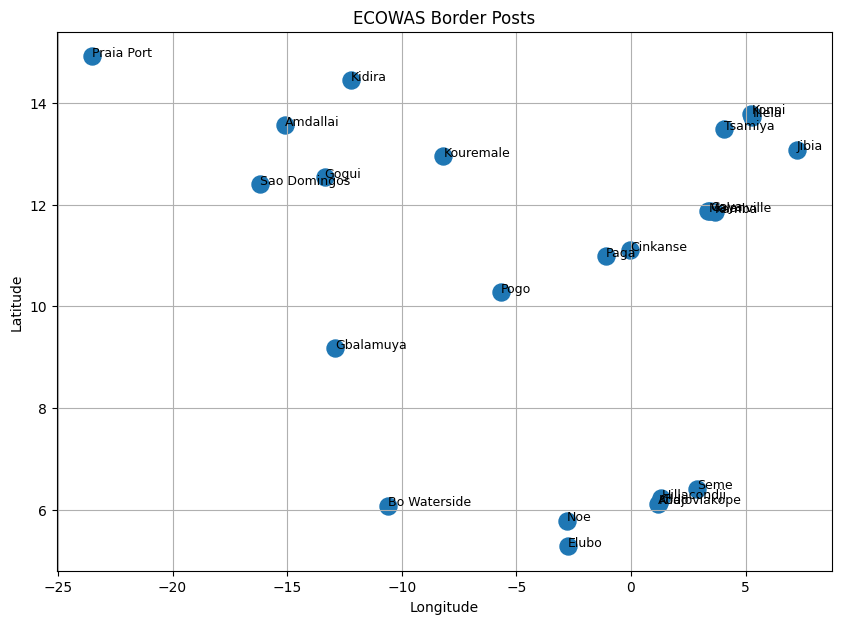

In [56]:
# ============================================================
# Chapter 7 - Static Map
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(

    border_activity["Longitude"],
    border_activity["Latitude"],
    s=150

)

for i in range(len(border_activity)):

    plt.text(

        border_activity["Longitude"][i],

        border_activity["Latitude"][i],

        border_activity["Border_Post"][i],

        fontsize=9

    )

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("ECOWAS Border Posts")

plt.grid(True)

plt.show()

## Install Folium

Folium enables the creation of interactive web maps.

In [57]:
# ============================================================
# Chapter 8 - Install Folium
# ============================================================

!pip install folium

print("Folium installed successfully.")

Folium installed successfully.


## Interactive Border Map

Generate an interactive map showing the location of each border post.

In [58]:
# ============================================================
# Chapter 9 - Interactive Map
# ============================================================

import folium

# Remove rows with missing coordinates
map_data = border_activity.dropna(
    subset=["Latitude", "Longitude"]
)

m = folium.Map(
    location=[10.8, 6.0],
    zoom_start=5
)

for _, row in map_data.iterrows():

    folium.Marker(

        location=[row["Latitude"], row["Longitude"]],

        popup=(
            f"{row['Border_Post']}<br>"
            f"Transactions: {row['Total_Transactions']:,}"
        ),

        tooltip=row["Border_Post"]

    ).add_to(m)

m

In [59]:
print(
    border_activity[
        border_activity["Latitude"].isna()
    ][["Border_Post"]]
)

Empty DataFrame
Columns: [Border_Post]
Index: []


## Export Interactive Map

Save the interactive map as an HTML file for sharing and GitHub.

In [60]:
# ============================================================
# Chapter 10 - Export Interactive Map
# ============================================================

m.save("ECOWAS_Border_Map.html")

print("Interactive map exported successfully.")

Interactive map exported successfully.


\## Export Border Activity Summary

Save the summarized border activity data for future analysis.

In [61]:
# ============================================================
# Chapter 11 - Export Summary
# ============================================================

border_activity.to_csv(

    "border_activity_summary.csv",

    index=False

)

print("Border activity summary exported successfully.")

Border activity summary exported successfully.


In [62]:
# ============================================================
# Chapter 12 - Verify Export
# ============================================================

import os

for file in sorted(os.listdir()):

    if file.endswith(".csv") or file.endswith(".html"):

        print(file)

ECOWAS_Border_Map.html
border_activity_summary.csv
trade_diversion_transactions.csv


# Geospatial Analytics Summary

This notebook demonstrated how simulated ECOWAS trade diversion data can be integrated with geographic information to support border intelligence.

Key outcomes include:

- Assignment of geographic coordinates
- Aggregation of border activity
- Static geographic visualization
- Interactive web-based mapping using Folium
- Export of geospatial datasets for future analysis

Geospatial analytics enables decision-makers to identify operational hotspots and visualize border activities spatially, supporting strategic planning and resource allocation.

# Geospatial Analytics Summary

## Overview

This notebook demonstrated how geospatial analytics can be integrated with simulated ECOWAS border trade data to support strategic border management and trade intelligence.

By linking transaction records with geographic coordinates, border activities can be visualized spatially, making it easier to identify operational hotspots and support evidence-based decision-making.

---

## Key Activities Completed

- Assigned geographic coordinates to each border post.
- Aggregated trade transactions by border location.
- Created a static map of ECOWAS border posts using Matplotlib.
- Developed an interactive web-based map using Folium.
- Exported geospatial datasets for future analysis and visualization.

---

## Business Value

Geospatial analytics provides decision-makers with the ability to:

- Monitor border activities geographically.
- Identify high-traffic and high-risk border locations.
- Improve allocation of inspection and security resources.
- Support regional trade planning and policy evaluation.
- Enhance situational awareness through interactive mapping.

---

## Deliverables Produced

The following files were generated during this notebook:

- `border_activity_summary.csv`
- `ECOWAS_Border_Map.html`

These outputs can be integrated into Power BI dashboards, Streamlit applications, and future analytical workflows.

# Border Location Reference Dataset

Export the border location reference table for reuse in geospatial analysis, Power BI, and Streamlit applications.

This dataset serves as a master lookup table containing border names, geographic coordinates, and border characteristics.

In [63]:
# ============================================================
# Chapter 14 - Export Border Locations
# ============================================================

border_locations = pd.DataFrame({

    "Border_Post": list(coordinates.keys()),

    "Latitude": [v[0] for v in coordinates.values()],

    "Longitude": [v[1] for v in coordinates.values()]

})

border_locations.to_csv(
    "border_locations.csv",
    index=False
)

print("border_locations.csv exported successfully.")

border_locations.head()

border_locations.csv exported successfully.


,Border_Post,Latitude,Longitude
0,Tsamiya,13.48,4.07
1,Kamba,11.85,3.65
2,Seme,6.41,2.88
3,Illela,13.73,5.30
4,Jibia,13.08,7.23


In [64]:
# ============================================================
# Chapter 15 - Verify Export
# ============================================================

import os

for file in sorted(os.listdir()):

    if file.endswith(".csv") or file.endswith(".html"):

        print(file)

ECOWAS_Border_Map.html
border_activity_summary.csv
border_locations.csv
trade_diversion_transactions.csv
